# DataFrame에서 날짜/시간(datetime) 타입 데이터 다루기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SPX 주가 데이터셋

In [2]:
file_path = "https://github.com/wesm/pydata-book/raw/refs/heads/3rd-edition/examples/spx.csv"

In [3]:
spx = pd.read_csv(file_path)

In [8]:
spx.head()

,Date,SPX
0,1990-02-01 00:00:00,328.79
1,1990-02-02 00:00:00,330.92
2,1990-02-05 00:00:00,331.85
3,1990-02-06 00:00:00,329.66
4,1990-02-07 00:00:00,333.75


In [7]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5472 non-null   object 
 1   SPX     5472 non-null   float64
dtypes: float64(1), object(1)
memory usage: 85.6+ KB


# 문자열 타입의 컬럼을 datetime 타입으로 변환

In [9]:
spx.Date = pd.to_datetime(spx.Date)

In [12]:
spx

,Date,SPX
0,1990-02-01,328.79
1,1990-02-02,330.92
2,1990-02-05,331.85
3,1990-02-06,329.66
4,1990-02-07,333.75
...,...,...
5467,2011-10-10,1194.89
5468,2011-10-11,1195.54
5469,2011-10-12,1207.25
5470,2011-10-13,1203.66


In [13]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5472 non-null   datetime64[ns]
 1   SPX     5472 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 85.6 KB


# csv 파일에서 DataFrame을 생성할 때 날짜/시간 컬럼과 형식을 지정

In [14]:
spx = pd.read_csv(file_path, parse_dates=["Date"],
                  date_format={"Date": "%Y-%m-%d %H:%M:%S"})

In [15]:
spx

,Date,SPX
0,1990-02-01,328.79
1,1990-02-02,330.92
2,1990-02-05,331.85
3,1990-02-06,329.66
4,1990-02-07,333.75
...,...,...
5467,2011-10-10,1194.89
5468,2011-10-11,1195.54
5469,2011-10-12,1207.25
5470,2011-10-13,1203.66


In [16]:
spx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5472 entries, 0 to 5471
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5472 non-null   datetime64[ns]
 1   SPX     5472 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 85.6 KB


# 기간별(연도별, 분기별, 월별, ...) 통계

In [18]:
# Date 컬럼(datetime 타입)을 인덱스로 변환.
spx_index = spx.set_index("Date")

In [23]:
spx_index

,SPX
Date,
1990-02-01,328.79
1990-02-02,330.92
1990-02-05,331.85
1990-02-06,329.66
1990-02-07,333.75
...,...
2011-10-10,1194.89
2011-10-11,1195.54
2011-10-12,1207.25


In [24]:
spx_index.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5472 entries, 1990-02-01 to 2011-10-14
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPX     5472 non-null   float64
dtypes: float64(1)
memory usage: 85.5 KB


In [27]:
# 연도별 주가 평균
spx_by_year = spx_index.resample(rule="YE").mean()

In [30]:
spx_by_year.head()

,SPX
Date,
1990-12-31,334.123506
1991-12-31,376.186324
1992-12-31,415.747008
1993-12-31,451.614822
1994-12-31,460.416508


In [31]:
spx_by_year.tail()

,SPX
Date,
2007-12-31,1477.184343
2008-12-31,1220.042055
2009-12-31,948.046389
2010-12-31,1139.965516
2011-12-31,1276.093015


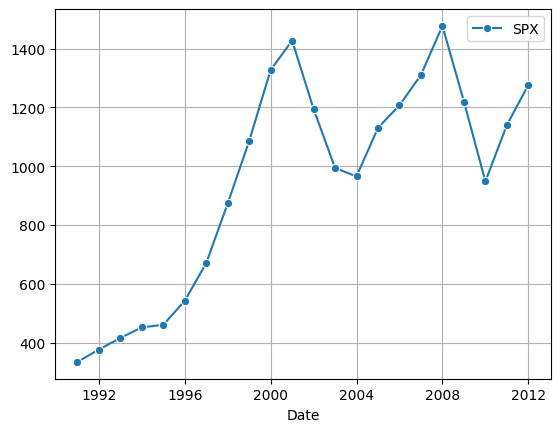

In [37]:
sns.lineplot(data=spx_by_year, marker="o")
plt.grid()
plt.show()

In [38]:
spx_by_quarter = spx_index.resample(rule="QE").mean()

In [40]:
spx_by_quarter.head(n=6)

,SPX
Date,
1990-03-31,334.751951
1990-06-30,349.796508
1990-09-30,335.881746
1990-12-31,316.562031
1991-03-31,352.282951
1991-06-30,378.665937


In [41]:
spx_by_quarter.tail(n=6)

,SPX
Date,
2010-09-30,1096.246875
2010-12-31,1204.585625
2011-03-31,1302.529032
2011-06-30,1318.332857
2011-09-30,1225.268438
2011-12-31,1171.356000


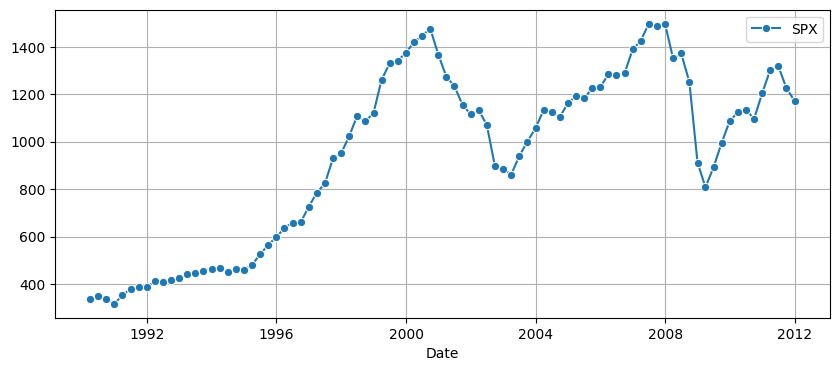

In [44]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=spx_by_quarter, marker="o")
plt.grid()
plt.show()

# banklist 데이터셋

*   [banklist.csv](https://github.com/JakeOh/202511_BD53/raw/refs/heads/main/datasets/banklist.csv) 파일을 읽고 데이터프레임을 생성.
*   데이터프레임을 생성할 때 날짜/시간(datetime) 타입으로 변환할 수 있는 모든 컬럼들은 날짜/시간 타입으로 변환.
*   연도별 파산한 은행 숫자 시각화.
*   분기별 파산한 은행 숫자 시각화.
*   월별 파산한 은행 숫자 시각화.
*   기간별 통계는 Closing Date를 기준으로.

In [45]:
file_path = "https://github.com/JakeOh/202511_BD53/raw/refs/heads/main/datasets/banklist.csv"

In [49]:
from ast import parse
banklist = pd.read_csv(file_path, parse_dates=["Closing Date", "Updated Date"],date_format={"Closing Date": "%d-%b-%y", "Updated Date": "%d-%b-%y"})

In [50]:
banklist.head()

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,2017-12-15,2017-12-20
1,The Farmers and Merchants State Bank of Argonia,Argonia,KS,17719,Conway Bank,2017-10-13,2017-10-20
2,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",2017-05-26,2017-07-26
3,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,2017-05-05,2017-07-26
4,First NBC Bank,New Orleans,LA,58302,Whitney Bank,2017-04-28,2017-12-05


In [51]:
banklist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              555 non-null    object        
 1   City                   555 non-null    object        
 2   ST                     555 non-null    object        
 3   CERT                   555 non-null    int64         
 4   Acquiring Institution  555 non-null    object        
 5   Closing Date           555 non-null    datetime64[ns]
 6   Updated Date           555 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 30.5+ KB


In [61]:
bank_by_year = banklist.resample(rule="YE", on="Closing Date")["Bank Name"].count()
bank_by_year

,Bank Name
Closing Date,
2000-12-31,2
2001-12-31,4
2002-12-31,11
2003-12-31,3
2004-12-31,4
2005-12-31,0
2006-12-31,0
2007-12-31,3
2008-12-31,25


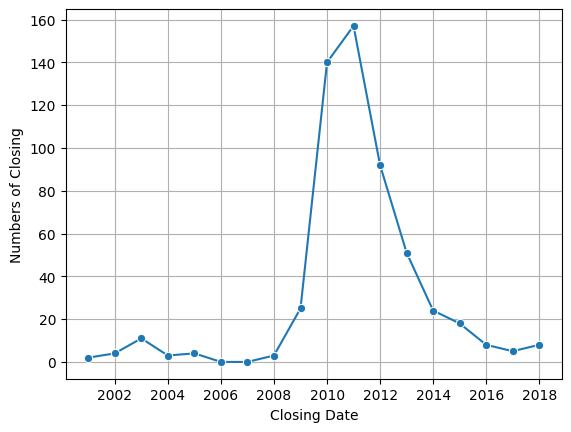

In [65]:
sns.lineplot(data=bank_by_year, marker="o")

plt.ylabel("Numbers of Closing")
plt.grid()
plt.show()

In [66]:
bank_by_Q = banklist.resample(rule="QE", on="Closing Date")["Bank Name"].count()
bank_by_Q

,Bank Name
Closing Date,
2000-12-31,2
2001-03-31,1
2001-06-30,1
2001-09-30,2
2001-12-31,0
...,...
2016-12-31,0
2017-03-31,3
2017-06-30,3


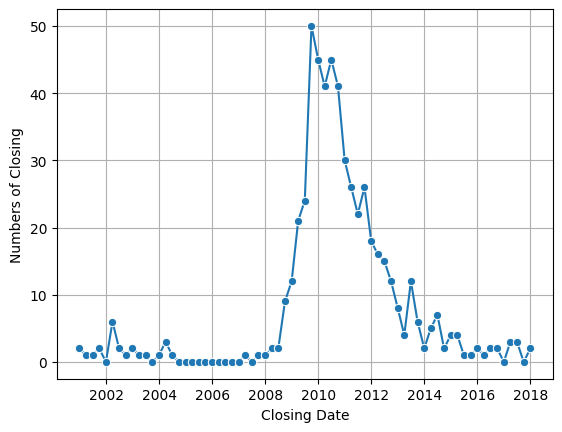

In [70]:
sns.lineplot(data=bank_by_Q, marker="o")

plt.ylabel("Numbers of Closing")
plt.grid()
plt.show()

In [71]:
bank_by_M = banklist.resample(rule="ME", on="Closing Date")["Bank Name"].count()
bank_by_M

,Bank Name
Closing Date,
2000-10-31,1
2000-11-30,0
2000-12-31,1
2001-01-31,0
2001-02-28,1
...,...
2017-08-31,0
2017-09-30,0
2017-10-31,1


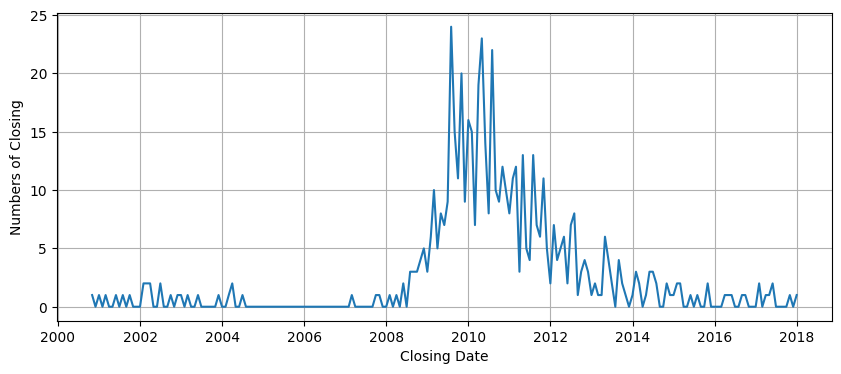

In [74]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=bank_by_M)

plt.ylabel("Numbers of Closing")
plt.grid()
plt.show()